## Perceptron vs Adaline (ADAtive LInear NEuron)
The difference is that the threshold_function is moved outside of the update loop. The linear value is used for error calculation instead.

<img src="images/perceptron.png" width=500>

In [28]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from classification_algos.perceptron_adaline import Perceptron

In [29]:
# get data
source = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.read_csv(source, header=None)

In [30]:
# explore df
print(df.head())
print(df.info())
print(df[4].unique())

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
 4   4       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


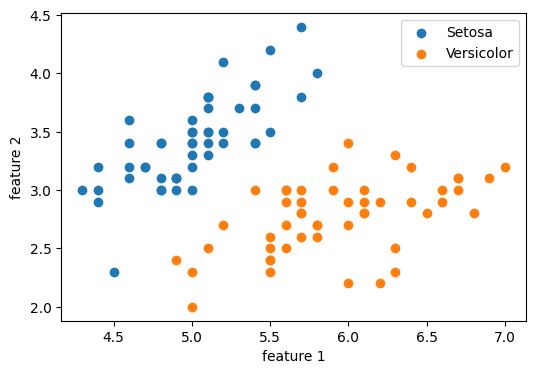

In [31]:
# visualize Iris-setosa vs Iris-versicolor
plt.figure(figsize=(6, 4))
plt.scatter(df.iloc[:50, 0], df.iloc[:50, 1])
plt.scatter(df.iloc[50:100, 0], df.iloc[50:100, 1])
plt.legend(['Setosa', 'Versicolor'])
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()


In [32]:
# get training dataset for Setosa vs Versicolor
X = df.iloc[:100,:4].values

categories = pd.Categorical(df.iloc[:100,4]).categories.values
y_labels = df.iloc[:100, 4].values
y = np.where(y_labels==categories[0], 0, 1)

In [33]:
pd.Categorical(df[4]).categories.values

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [34]:
# train perceptron
perceptron = Perceptron(model="perceptron", n_iter=200)
perceptron.fit(X, y)

In [35]:
# traina daline
adaline = Perceptron(model="adaline", n_iter=200, lr=0.01)
adaline.fit(X, y)

adaline_hard_errors = sum(adaline.predict(X) == y)

In [36]:
print(adaline.errors_)

[97, 97, 96, 95, 94, 91, 90, 88, 86, 84, 82, 80, 78, 74, 72, 68, 63, 63, 61, 61, 58, 57, 57, 56, 54, 53, 50, 49, 47, 46, 45, 44, 41, 39, 38, 38, 37, 37, 36, 33, 29, 28, 28, 27, 26, 24, 24, 24, 24, 24, 23, 23, 22, 21, 21, 21, 21, 21, 21, 20, 20, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 17, 17, 17, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]


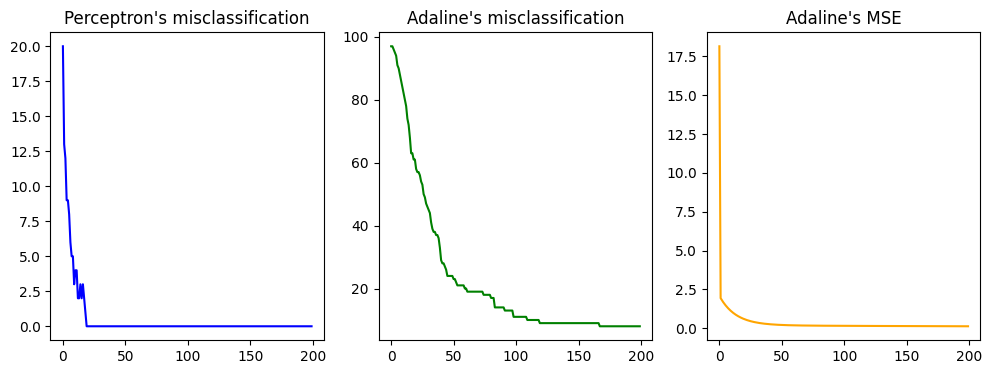

In [37]:
# compare errors
n = list(range(perceptron.n_iter))

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(n, perceptron.errors_, color="blue")
axs[0].set_title("Perceptron's misclassification")

axs[1].plot(n, adaline.errors_, color="green")
axs[1].set_title("Adaline's misclassification")

axs[2].plot(n, adaline.mse_, color="orange")
axs[2].set_title("Adaline's MSE")

plt.show()